### Permutation Group Classes

In [1]:
from itertools import chain
from typing import Any, Optional, List, Union, Sequence
from functools import cached_property, reduce
from math import gcd
from IPython.display import Latex

class PermAction:
    def __init__(
        self,
        m: Optional[List[int]] = None,
        degree: Optional[int] = None,
        name: Optional[str] = None,
    ):
        # m is a list representing the action of the permutation on 1-indexed points
        # For example, if m = [2, 1, 3], then point 1 maps to 2, point 2 maps to 1, and point 3 maps to 3.
        if m is None:
            assert degree is not None, "Either m or n must be provided."
            m = list(range(1, degree + 1))
        self.m = m
        self.degree = len(m)
        self.name = name or self._cycle_notation()

    def inverse(self) -> "PermAction":
        # Compute the inverse permutation
        inv = [0] * self.degree
        for i in range(self.degree):
            inv[self.m[i] - 1] = i + 1
        return PermAction(inv)

    def __mul__(self, other: "PermAction") -> "PermActionChain":
        if not isinstance(other, PermAction):
            return NotImplemented
        if self.degree != other.degree:
            raise ValueError("Permutations must have the same degree to be composed.")
        # Composition of two permutations
        return PermActionChain([self, other])

    def __rmul__(self, left: int) -> int:
        result = self(left)
        assert isinstance(result, int)
        return result

    def __call__(self, x: int) -> int:
        if isinstance(x, int):
            assert 1 <= x <= self.degree, "Input must be in the range [1, degree]"
            return self.m[x - 1]
        else:
            raise TypeError("Input must be an integer.")

    def compound(self, other: "PermAction") -> "PermAction":
        if self.degree != other.degree:
            raise ValueError("Permutations must have the same degree to be composed.")
        return PermAction([self.m[other.m[i] - 1] for i in range(self.degree)])

    def __eq__(self, right: Union["PermAction", "PermActionChain"]) -> bool:
        if isinstance(right, PermActionChain):
            return self == right.action
        elif isinstance(right, PermAction):
            return self.m == right.m
        return NotImplemented

    def __hash__(self) -> int:
        return hash(tuple(self.m))

    @cached_property
    def action(self) -> List[int]:
        return self.m

    @cached_property
    def degree(self) -> int:
        return self.degree

    @cached_property
    def is_identity(self) -> bool:
        return all(self.m[i] == i + 1 for i in range(self.degree))

    def __repr__(self) -> str:
        return self.name

    @cached_property
    def c(self) -> str:
        return self._cycle_notation()

    def _cycles(self) -> List[List[int]]:
        visited = [False] * self.degree
        cycles = []
        for i in range(self.degree):
            if not visited[i]:
                cycle = []
                x = i + 1
                while not visited[x - 1]:
                    visited[x - 1] = True
                    cycle.append(x)
                    x = self.m[x - 1]
                if len(cycle) > 0:
                    cycles.append(cycle)
        return cycles

    @cached_property
    def order(self) -> int:
        def lcm(a: int, b: int) -> int:
            return a * b // gcd(a, b)

        cycle_lengths = [len(cycle) for cycle in self._cycles()]
        return reduce(lcm, cycle_lengths, 1) if cycle_lengths else 1

    def _cycle_notation(self) -> str:
        cycles = self._cycles()
        cycle_str = "".join(
            "({})".format(" ".join(map(str, cycle)))
            for cycle in cycles
            if len(cycle) > 1
        )
        return cycle_str if cycle_str else "()"


class PermActionChain:
    """
    A chain of permutation actions applied in sequence, from left to right

    for example, if the chain consists of actions [p1, p2, p3], then applying the chain to a point x
    results in p3(p2(p1(x))).
    """

    def __init__(
        self, actions: Optional[List[PermAction]] = None, degree: Optional[int] = None
    ):
        self.degree = actions[0].degree if actions else degree or -1

        if self.degree == -1:
            raise ValueError("Degree must be specified if actions list is empty.")

        if actions is None:
            assert degree is not None, "Either actions or degree must be provided."
            actions = [PermAction(degree=self.degree, name="e")]
        self.actions = actions

        self.actions = self._simplify()

    def _simplify(self) -> List[PermAction]:
        # Simplify the chain by removing identity actions and by merging
        # with previously appended simplified actions when possible.
        #
        # Approach:
        # - Process the original actions in groups of consecutive identical actions.
        # - For each group compute effective_count = count % action.order.
        # - Keep a stack of (action, count) for the simplified chain.
        #   When adding an effective_count for an action, if the stack top
        #   has the same action, combine counts modulo the action order and
        #   pop if the combined count is 0. This allows "looking back" and
        #   merging with already appended elements when intermediate groups
        #   cancel out.

        stack = []  # will hold tuples (PermAction, int)
        i = 0
        n = len(self.actions)
        while i < n:
            current_action = self.actions[i]
            action_count = 1
            while (
                i + action_count < n
                and self.actions[i + action_count] == current_action
            ):
                action_count += 1
            effective_count = action_count % current_action.order

            if effective_count > 0:
                if stack and stack[-1][0] == current_action:
                    prev_action, prev_count = stack[-1]
                    new_count = (prev_count + effective_count) % current_action.order
                    if new_count == 0:
                        stack.pop()
                    else:
                        stack[-1] = (prev_action, new_count)
                else:
                    stack.append((current_action, effective_count))

            i += action_count

        # Expand the stack into the simplified actions list
        simplified_actions: List[PermAction] = []
        for action, count in stack:
            if not action.is_identity:
                simplified_actions += [action] * count

        if len(simplified_actions) == 0:
            simplified_actions = [PermAction(degree=self.degree, name="e")]

        self.reduced_actions = stack  # Store for debugging purposes
        self.reduced_length = sum(
            min(count, x.order - count % x.order) for x, count in stack
        )
        return simplified_actions

    @cached_property
    def inverse(self) -> "PermActionChain":
        inversion_chain = []
        for action in reversed(self.actions):
            inversion_chain += [action] * (action.order - 1)
        return PermActionChain(inversion_chain, degree=self.degree)

    def __repr__(self) -> str:
        actions_str = "".join(repr(action) for action in self.actions)
        return actions_str

    @cached_property
    def is_identity(self) -> bool:
        return self.action.is_identity

    @cached_property
    def action(self) -> PermAction:
        # Compute the overall action of the chain
        result = PermAction(degree=self.degree)
        for action in self.actions:
            result = action.compound(result)
        assert isinstance(result, PermAction)
        return result

    @cached_property
    def c(self) -> str:
        return self.action.c

    @cached_property
    def order(self) -> int:
        return self.action.order

    def __call__(self, x: int) -> int:
        result = self.action(x)
        assert isinstance(result, int)
        return result

    def __len__(self) -> int:
        if self.action.is_identity:
            return 0
        return self.reduced_length

    def __eq__(self, right: Union[PermAction, "PermActionChain"]) -> bool:
        if isinstance(right, PermActionChain):
            return self.action == right.action
        elif isinstance(right, PermAction):
            return self.action == right
        return NotImplemented

    def __mul__(
        self, other: Union["PermAction", "PermActionChain"]
    ) -> "PermActionChain":
        if isinstance(other, PermAction):
            if self.degree != other.degree:
                raise ValueError(
                    "Chain and action must have the same degree to be composed."
                )
            new_actions = self.actions + [other]
            return PermActionChain(new_actions)
        elif isinstance(other, PermActionChain):
            if self.degree != other.degree:
                print(self, other)
                print(self.degree, other.degree)
                raise ValueError("Chains must have the same degree to be composed.")
            new_actions = self.actions + other.actions
            return PermActionChain(new_actions)
        else:
            return NotImplemented

    def __rmul__(
        self, other: Union[int, "PermAction", "PermActionChain"]
    ) -> Union[int, "PermActionChain"]:
        if isinstance(other, int):
            # Apply the chain to a single point from the left
            result = self.action(other)
            assert isinstance(result, int)
            return result
        elif isinstance(other, PermAction):
            if self.degree != other.degree:
                raise ValueError(
                    "Action and chain must have the same degree to be composed."
                )
            new_actions = [other] + self.actions
            return PermActionChain(new_actions)
        elif isinstance(other, PermActionChain):
            if self.degree != other.degree:
                raise ValueError(
                    "Action and chain must have the same degree to be composed."
                )
            new_actions = other.actions + self.actions
            return PermActionChain(new_actions)
        else:
            return NotImplemented

    def __hash__(self) -> int:
        return hash(tuple(self.actions))

    def __lt__(self, other: "PermActionChain") -> bool:
        if not isinstance(other, PermActionChain):
            return NotImplemented
        return len(self.actions) < len(other.actions)


    def to_latex(self) -> Latex:
        latex_str = "$"
        for action, count in self.reduced_actions:
            if action.order - count % action.order < count:
                count = action.order - count % action.order
                latex_str += "\\overline{" + str(action) + "}"
            else:
                latex_str += str(action)
            if count > 1:
                latex_str += "^{" + str(count) + "}"
        return Latex(latex_str + "$")
    
class PermGroup:
    def __init__(self, degree: int):
        self.degree = degree

    def __repr__(self) -> str:
        return f"S_{self.degree}"

    @cached_property
    def e(self) -> PermAction:
        return PermAction(list(range(1, self.degree + 1)), name="e")

    def from_cycle(self, str_cycle: str, name: Optional[str] = None) -> PermAction:
        # Create a PermAction from cycle notation string
        m = list(range(1, self.degree + 1))
        cycles = [
            [int(elem) for elem in sub_cycle[1:].split()]
            for sub_cycle in str_cycle.strip().split(")")
            if sub_cycle
        ]
        for cycle in cycles:
            if len(cycle) > 0:
                points = list(map(int, cycle))
                for i in range(len(points)):
                    m[points[i] - 1] = points[(i + 1) % len(points)]
        return PermAction(m, name=name)

    def orbit(
        self, point: int, generators: Union[List[PermAction], List[PermActionChain]]
    ) -> dict[int, PermActionChain]:
        # Compute the orbit of a point under the action of the group generated by the given generators
        orbit = {point: PermActionChain([self.e])}
        to_visit = [point]
        while to_visit:
            current = to_visit.pop()
            for gen in generators:
                image = gen(current)
                if (image not in orbit) or (
                    len(orbit[current] * gen) < len(orbit[image])
                ):
                    orbit[image] = orbit[current] * gen
                    to_visit.append(image)

        return orbit

    def schreier_generators(
        self, point: int, generators: Union[List[PermAction], List[PermActionChain]]
    ) -> List[PermActionChain]:
        orbit = self.orbit(point, generators)
        schreier_gens = []
        seen_set = set()
        for x, chain in orbit.items():
            for gen in generators:
                image = gen(x)
                if image in orbit:
                    u = chain * gen
                    v = orbit[image]
                    schreier_gen = u * v.inverse
                    if (
                        not schreier_gen.is_identity
                        and schreier_gen.action not in seen_set
                    ):
                        schreier_gens.append(schreier_gen)
                        seen_set.add(schreier_gen.action)
        return schreier_gens

    def schreier_sims(
        self,
        generators: Union[List[PermAction], List[PermActionChain]],
        base: Optional[Sequence[int]] = None,
    ) -> List[List[PermActionChain]]:
        # Compute the Schreier-Sims generators for the group generated by the given generators
        if base is None:
            base = range(1, self.degree)
        G = [
            g if isinstance(g, PermActionChain) else PermActionChain([g])
            for g in generators
            if not g.is_identity
        ]
        schreier_sims_gens: List[List[PermActionChain]] = [G]
        current_gens = G
        for i in base:
            level_gens = self.schreier_generators(i, current_gens)
            schreier_sims_gens.append(level_gens)
            current_gens = level_gens
        return schreier_sims_gens

    def sift_candidates(
        self,
        level_idx,
        candidate: Union[PermAction, PermActionChain],
        current_sgs: List[PermActionChain],
        base: Optional[Sequence[int]] = None,
    ) -> Optional[PermActionChain]:

        if base is None:
            base = range(1, self.degree)

        bsgs_test = self.schreier_sims(current_sgs, base=base[level_idx + 1 :])
        test_word = self.word_generation(
            candidate, bsgs_test, base=base[level_idx + 1 :]
        )

        if test_word is not None:
            # print("Redundant:", candidate, candidate.action, "Expressed as: ", test_word, test_word.action)
            return test_word
        else:
            # print("Not Redundant:", candidate, candidate.action)
            return None

    def schreier_sims_with_sifting(
        self,
        generators: Union[List[PermAction], List[PermActionChain]],
        base: Optional[Sequence[int]] = None,
    ) -> List[List[PermActionChain]]:
        # Compute the Schreier-Sims generators for the group generated by the given generators
        if base is None:
            base = range(1, self.degree)
        G: List[PermActionChain] = [
            g if isinstance(g, PermActionChain) else PermActionChain([g])
            for g in generators
            if not g.is_identity
        ]
        schreier_sims_gens: List[List[PermActionChain]] = [G]
        current_gens = G
        for level_idx, b in enumerate(base):
            level_gens: List[PermActionChain] = []
            candidates = self.schreier_generators(b, current_gens)
            for candidate in candidates:
                redundant_word = self.sift_candidates(
                    level_idx, candidate, level_gens, base=base
                )
                if redundant_word is None:
                    level_gens.append(candidate)
            schreier_sims_gens.append(level_gens)
            current_gens = level_gens
        return schreier_sims_gens
    
    def word_generation(
        self,
        g: Union[PermAction, PermActionChain],
        bsgs: List[List[PermActionChain]],
        base: Optional[Sequence[int]] = None,
    ) -> Union[PermActionChain, None]:
        # Given a permutation g and a list of Schreier-Sims generators (bsgs),
        # attempt to express g as a word in the generators.
        if base is None:
            base = range(1, self.degree)
        current = g if isinstance(g, PermActionChain) else PermActionChain([g])
        word = PermActionChain(degree=self.degree)
        for level_idx, b in enumerate(base):
            x = current(b)
            orbit = self.orbit(b, bsgs[level_idx])
            if not x in orbit:
                return None
            u = orbit[x]
            word = u * word
            current = current * u.inverse
        if current.is_identity:
            return word
        return None

### Classes Tests

In [2]:
# write some test cases for the PermAction class, including tests for composition, inversion, cycle notation, and order.
def test_permaction():
    # Test identity permutation
    p1 = PermAction([1, 2, 3])
    assert p1.is_identity
    assert p1.order == 1
    assert p1.c == "()"

    # Test a simple permutation
    p2 = PermAction([2, 3, 1])
    assert not p2.is_identity
    assert p2(1) == 2
    assert p2(2) == 3
    assert p2(3) == 1
    assert p2.c == "(1 2 3)"
    assert p2.order == 3

    # Test inverse
    p2_inv = p2.inverse()
    assert p2_inv(1) == 3
    assert p2_inv(2) == 1
    assert p2_inv(3) == 2
    assert (p2 * p2_inv).is_identity

    # Test composition
    p3 = PermAction([3, 1, 2])
    p4 = p2 * p3
    assert p4(1) == 1
    assert p4(2) == 2
    assert p4(3) == 3
    assert p4.is_identity

    # Test cycle notation and order for a more complex permutation
    p5 = PermAction([2, 1, 4, 3])
    assert p5.c == "(1 2)(3 4)"
    assert p5.order == 2

    print("All tests passed!")

test_permaction()

All tests passed!


In [3]:
# write some test cases for the PermActionChain class, including tests for composition, application to points, and simplification.
def test_permactionchain():
    # Create some basic PermActions
    p1 = PermAction([2, 1, 3], name="p1")  # (1 2)
    p2 = PermAction([1, 3, 2], name="p2")  # (2 3)

    # Test creating a chain
    chain = PermActionChain([p1, p2])
    assert len(chain) == 2
    assert chain(1) == 3  # p1(1) = 2, p2(2) = 3
    assert chain(2) == 1  # p1(2) = 1, p2(1) = 1
    assert chain(3) == 2  # p1(3) = 3, p2(3) = 2

    # Test composition with another action
    p3 = PermAction([3, 2, 1], name="p3")  # (1 3)
    new_chain = chain * p3
    assert len(new_chain) == 3
    assert new_chain(1) == 1
    assert new_chain(2) == 3
    assert new_chain(3) == 2

    # Test simplification
    identity = PermAction(list(range(1, 4)), name="e")
    chain_with_identity = PermActionChain([p1, identity, p2, identity])
    assert len(chain_with_identity) == 2
    assert chain_with_identity(1) == chain_with_identity(1)
    assert chain_with_identity(2) == chain_with_identity(2)
    assert chain_with_identity(3) == chain_with_identity(3)

    print("All tests passed!")

test_permactionchain()

All tests passed!


### Test on orbit and all

In [ ]:
S4 = PermGroup(4)
p = S4.from_cycle("(1 2 3)", name="p")
q = S4.from_cycle("(1 2 4)", name="q") 

In [5]:
p * q *(p * q).inverse

e

In [6]:
p * p * p

e

In [7]:
p.degree

4

In [8]:
S4.e.degree

4

In [9]:
S4.orbit(1, [p, q])

{1: e, 2: p, 3: pp, 4: pq}

In [10]:
S4.schreier_generators(1, [p, q])

[qpp, ppqp]

### 2x2 Rubik's Cube Square (not face) Group

```
   2 ---- 4
  /|     /|
 1 ---- 3 |
 | 6 ---| 8
 |/     |/
 5 ---- 7
```

In [11]:
S8 = PermGroup(8)
T = S8.from_cycle("(1 2 4 3)", name="T")
R = S8.from_cycle("(3 4 8 7)", name="R")
B = S8.from_cycle("(2 4 8 6)", name="B")

In [12]:
bsgs = S8.schreier_sims([R, B, T])

In [13]:
bsgs2 = S8.schreier_sims_with_sifting([R, B, T])

In [14]:
[x.action for x in bsgs2[6]]

[(7 8)]

In [15]:
test_idx = 1
bsgs[1][:test_idx], bsgs[1][1]

([R], B)

In [16]:
A = PermAction(m=[6,2,4,7,5,3,1,8])

In [17]:
A_r_word = S8.word_generation(A, bsgs2)

In [18]:
len(A_r_word)

12

In [19]:
A_r_word.reduced_actions

[(T, 1),
 (R, 1),
 (T, 3),
 (R, 3),
 (B, 3),
 (R, 3),
 (B, 1),
 (R, 1),
 (T, 1),
 (B, 1),
 (R, 1),
 (B, 1)]

In [20]:
(A_r_word * A.inverse()).action

()

In [21]:
[len(x) for x in bsgs]

[3, 15, 54, 23, 5, 5, 1, 0]

In [22]:
level_idx = 1
test_idx = 10

accepted_generators = bsgs[level_idx][:test_idx]
candidate = bsgs[level_idx][test_idx]

bsgs_test = S8.schreier_sims(accepted_generators, base=range(level_idx+1,9))
test_word = S8.word_generation(candidate, bsgs_test, base=range(level_idx+1,9))

if test_word is not None:
    print("Redundant:", candidate, candidate.action, "Expressed as: ", test_word, test_word.action)
else:
    print("Not Redundant:", candidate, candidate.action)

Redundant: TBRRBRRBBBTTT (4 8 6 7) Expressed as:  TTBBBTTTBBBRR (4 8 6 7)


In [23]:
[x.action for x in bsgs[level_idx]]

[(3 4 8 7),
 (2 4 8 6),
 (2 8 7 4),
 (2 4 3 6 8),
 (2 8 6 4 7),
 (3 6 4 7),
 (2 7 4 3 6),
 (2 8 3 6),
 (2 8 6 3 4),
 (2 6 3 4 7),
 (4 8 6 7),
 (2 3 6 7),
 (2 7 6 4),
 (2 7 4 6 8),
 (3 8 6 7)]

In [24]:
[x.action for x in bsgs[3]]

[(4 6 7),
 (4 8 6 7),
 (4 8 7 6),
 (4 7 8),
 (4 7),
 (4 8),
 (4 7 6 8),
 (4 6 8 7),
 (6 7 8),
 (4 7 8 6),
 (4 7)(6 8),
 (4 6 7 8),
 (6 7),
 (6 8),
 (4 6)(7 8),
 (4 8)(6 7),
 (4 7 6),
 (4 8 7),
 (4 6),
 (4 6 8),
 (6 8 7),
 (4 8 6),
 (7 8)]

In [25]:
O2 = S8.orbit(2, [R, B])

In [26]:
O2

{2: e, 4: B, 8: BR, 7: BRR, 6: BRB, 3: BRRR}

In [27]:
(B*R*B.inverse()).action

(2 4 7 3)

In [28]:
[x.action for x in S8.schreier_generators(2, [R, B])]

[(3 4 8 7), (3 7 4 8 6), (3 8 6 7), (3 4 7 6), (3 6 8 4 7), (4 7 8 6)]

In [29]:
G1 = S8.schreier_generators(1, [T, R, B])
[x.action for x in G1]

[(3 4 8 7),
 (2 4 8 6),
 (2 8 7 4),
 (2 8 6 3 4),
 (2 7 8 6 3),
 (2 4 3 8 7),
 (3 8 6 4),
 (2 7 4 3),
 (3 7 8 4),
 (2 7 8 3 4),
 (2 6 3 7),
 (3 7 4 6),
 (2 8 7 3),
 (2 6)(3 8 7 4)]

In [30]:
len(G1)

14

In [31]:
G2 = S8.schreier_generators(2, G1[:14])
len(G2), [x.action for x in G2]

(50,
 [(3 4 8 7),
  (3 7)(4 6 8),
  (4 6 7),
  (3 6 4 7),
  (3 4)(6 8 7),
  (3 8 6 4),
  (3 6 8),
  (3 7 8 4),
  (3 4 6 7 8),
  (3 7 4 6),
  (3 6 8 4),
  (4 7 6 8),
  (3 7 4 8 6),
  (4 7)(6 8),
  (3 4 6 8),
  (3 6 7 4 8),
  (3 7 6 4),
  (3 7)(4 8),
  (3 6)(4 7),
  (3 4)(6 7 8),
  (3 7 6 8),
  (3 7 4)(6 8),
  (3 8 7 6),
  (3 6 4)(7 8),
  (3 4 6 7),
  (3 7)(6 8),
  (4 6 8 7),
  (3 8 7 4),
  (3 7 6),
  (3 4 7)(6 8),
  (3 8 6 7),
  (3 8 4 7 6),
  (3 8 7)(4 6),
  (3 7)(4 8 6),
  (3 8)(4 7),
  (3 4 7 8),
  (3 4 7 6),
  (3 6 8 4 7),
  (3 8)(4 7 6),
  (3 4 8 6 7),
  (3 8 6)(4 7),
  (4 6 7 8),
  (3 6 7 4),
  (3 7 6 8 4),
  (3 7)(4 6),
  (3 7 8 6),
  (4 7 8 6),
  (3 7 8)(4 6),
  (3 8)(6 7),
  (6 8)])

In [32]:
G3 = S8.schreier_generators(3, G2)
len(G3), [x.action for x in G3]

(23,
 [(4 6 7),
  (6 8),
  (4 7 6),
  (4 8 6 7),
  (4 8 7),
  (4 6 8 7),
  (4 6)(7 8),
  (4 7),
  (4 7 6 8),
  (4 7 8 6),
  (4 7)(6 8),
  (6 8 7),
  (6 7 8),
  (4 8)(6 7),
  (4 6 8),
  (4 8),
  (4 8 7 6),
  (4 8 6),
  (4 6 7 8),
  (6 7),
  (4 6),
  (4 7 8),
  (7 8)])

In [33]:
G4 = S8.schreier_generators(4, G3)
[x.action for x in G4]

[(6 8), (6 7 8), (7 8), (6 7), (6 8 7)]

In [34]:
G5 = S8.schreier_generators(5, G4)
[x.action for x in G5]

[(6 8), (6 7 8), (7 8), (6 7), (6 8 7)]

In [35]:
G6 = S8.schreier_generators(6, G5)
[x.action for x in G6]

[(7 8)]

In [36]:
G7 = S8.schreier_generators(7, G6)
[x.action for x in G7]

[]

In [37]:
[len(x) for x in G5]

[11, 10, 13, 9, 8]

In [38]:
G5

[TTBRRRTTRRBRRRBBB,
 TTTRTTBBBRRRTRRRTTTBBB,
 TTRBBTTTBBBRRRBBBTRRRTTTBBB,
 BBRRRBBBRTRRRTTTBBB,
 BTTTRTTRBBBR]

In [39]:
S3 = PermGroup(3)
c1 = S3.from_cycle("(1 3)", name="c1")
c2 = S3.from_cycle("(1 2 3)", name="c2")
c3 = S3.from_cycle("(2 3)", name="c3")
c4 = S3.from_cycle("(1 2)", name="c4")
c5 = S3.from_cycle("(1 3 2)", name="c5")


In [40]:
bsgs1 = S3.schreier_sims([c1, c2])

In [41]:
bsgs1

[[c1, c2], [c1c2], []]

In [42]:
(c1 * c2).action

(2 3)

In [43]:
(c2 * c1).c

'(1 2)'

In [44]:
PermActionChain(degree=S3.degree)

e

In [45]:
bsgs1

[[c1, c2], [c1c2], []]

In [46]:
S3.word_generation(c5, bsgs1) 

c1c2c1

In [47]:
c5

c5

In [48]:
(c1 * c2 * c1).action

(1 3 2)

In [49]:
c4.c

'(1 2)'

In [50]:
(c1 * c2).inverse

c2c2c1

In [51]:
(c1 * c2) * (c1 * c2).inverse

e

In [52]:
(c1*c2).action

(2 3)

In [53]:
c4.c

'(1 2)'

In [54]:
(c2 * c1 * c2).action

(1 3)

In [55]:
(c1*c2).action

(2 3)

In [56]:
S24 = PermGroup(24)
T = PermAction(m=[1,15,16,4,5,2,3,8,9,6,7,12,13,14,10,11,17,18,19,20,22,23,24,21], name="T")
R = PermAction(m=[1,2,23,24,6,7,8,5,19,20,11,12,13,14,15,16,17,18,3,4,21,22,9,10], name="R")
B = PermAction(m=[1,2,3,4,5,6,20,17,12,9,10,11,22,14,23,16,15,18,19,13,21,7,8,24], name="B")

In [57]:
bsgs_S24 = S24.schreier_sims_with_sifting([R, B, T])

In [112]:
bsgs_S24

[[R, B, T],
 [R, B, T],
 [R, B, TRTTT],
 [B, TRTTT, RTRTTTBRRR],
 [B, RTRTTTBRRR, TRTTTRTRTTTBRRRTRRRTTTBBTRTTT],
 [B, RTRTTTBRRR, TRTTTRTRTTTBRRRTRRRTTTBBTRTTT],
 [B, RTRTTTBRRR, TRTTTRTRTTTBRRRTRRRTTTBBTRTTT],
 [TRTTTRTRTTTBRRRTRRRTTTBBTRTTTBBBRBBBTRRRTTTRRRB,
  BRTRTTTBRRR,
  BTRTTTRTRTTTBRRRTRRRTTTBBTRTTTBRBBBTRRRTTTRRRB],
 [BTRTTTRTRTTTBRRRTRRRTTTBBTRTTTBRBBBTRRRTTTRRRBRBBBTRRRTTTRRRBBB,
  TRTTTRTRTTTBRRRTRRRTTTBBTRTTTBBBRBBBTRRRTTTRRRBBTRTTTRTRTTTBRRRTRRRTTTBBTRTTTBRBBBTRRRTTTRRRB],
 [BTRTTTRTRTTTBRRRTRRRTTTBBTRTTTBRBBBTRRRTTTRRRBRBBBTRRRTTTRRRBBB,
  TRTTTRTRTTTBRRRTRRRTTTBBTRTTTBBBRBBBTRRRTTTRRRBBTRTTTRTRTTTBRRRTRRRTTTBBTRTTTBRBBBTRRRTTTRRRB],
 [BTRTTTRTRTTTBRRRTRRRTTTBBTRTTTBRBBBTRRRTTTRRRBRBBBTRRRTTTRRRBBB,
  TRTTTRTRTTTBRRRTRRRTTTBBTRTTTBBBRBBBTRRRTTTRRRBBTRTTTRTRTTTBRRRTRRRTTTBBTRTTTBRBBBTRRRTTTRRRB],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 []]

In [85]:
[(g, [x.action for x in g]) for g in bsgs_S24]

[([R, B, T],
  [(3 23 9 19)(4 24 10 20)(5 6 7 8),
   (7 20 13 22)(8 17 15 23)(9 12 11 10),
   (2 15 10 6)(3 16 11 7)(21 22 23 24)]),
 ([R, B, T],
  [(3 23 9 19)(4 24 10 20)(5 6 7 8),
   (7 20 13 22)(8 17 15 23)(9 12 11 10),
   (2 15 10 6)(3 16 11 7)(21 22 23 24)]),
 ([R, B, TRTTT],
  [(3 23 9 19)(4 24 10 20)(5 6 7 8),
   (7 20 13 22)(8 17 15 23)(9 12 11 10),
   (4 23 15 20)(5 10 11 8)(7 22 9 19)]),
 ([B, TRTTT, RTRTTTBRRR],
  [(7 20 13 22)(8 17 15 23)(9 12 11 10),
   (4 23 15 20)(5 10 11 8)(7 22 9 19),
   (7 8 23 9 10 20)(11 17 15 13 22 12)]),
 ([B, RTRTTTBRRR, TRTTTRTRTTTBRRRTRRRTTTBBTRTTT],
  [(7 20 13 22)(8 17 15 23)(9 12 11 10),
   (7 8 23 9 10 20)(11 17 15 13 22 12),
   (7 11 23 22 10 15)(8 20 9)]),
 ([B, RTRTTTBRRR, TRTTTRTRTTTBRRRTRRRTTTBBTRTTT],
  [(7 20 13 22)(8 17 15 23)(9 12 11 10),
   (7 8 23 9 10 20)(11 17 15 13 22 12),
   (7 11 23 22 10 15)(8 20 9)]),
 ([B, RTRTTTBRRR, TRTTTRTRTTTBRRRTRRRTTTBBTRTTT],
  [(7 20 13 22)(8 17 15 23)(9 12 11 10),
   (7 8 23 9 10 20)(11 17 15 13

### Plotting code

In [86]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from typing import Literal

In [87]:
class Cube2x2:
    def __init__(self):
        self.state = list(range(1, 25))

    def _calc_square_coordinates(
        self, origin_point, axis_direction: Literal["xy", "xz", "yz"]
    ):
        x, y, z = origin_point

        if axis_direction == "xy":
            square = [[x, y, z], [x + 1, y, z], [x + 1, y + 1, z], [x, y + 1, z]]
        elif axis_direction == "xz":
            square = [[x, y, z], [x + 1, y, z], [x + 1, y, z + 1], [x, y, z + 1]]
        elif axis_direction == "yz":
            square = [[x, y, z], [x, y + 1, z], [x, y + 1, z + 1], [x, y, z + 1]]

        # return Poly3DCollection([square], facecolors=color, linewidths=2, edgecolors="grey", alpha=.50)
        return square

    def _get_face_polygons(self, offsets=[0, 0, 0]):
        FACE_LUT = {
            1: ((0, 0, 0), "xz", "red"),
            2: ((0, 0, 1), "xz", "red"),
            3: ((1, 0, 1), "xz", "red"),
            4: ((1, 0, 0), "xz", "red"),
            5: ((2, 0, 0), "yz", "green"),
            6: ((2, 0, 1), "yz", "green"),
            7: ((2, 1, 1), "yz", "green"),
            8: ((2, 1, 0), "yz", "green"),
            9: ((1, 2 + offsets[0], 0), "xz", "orange"),
            10: ((1, 2 + offsets[0], 1), "xz", "orange"),
            11: ((0, 2 + offsets[0], 1), "xz", "orange"),
            12: ((0, 2 + offsets[0], 0), "xz", "orange"),
            13: ((0 - offsets[1], 1, 0), "yz", "blue"),
            14: ((0 - offsets[1], 0, 0), "yz", "blue"),
            15: ((0 - offsets[1], 1, 1), "yz", "blue"),
            16: ((0 - offsets[1], 0, 1), "yz", "blue"),
            17: ((0, 1, -offsets[2]), "xy", "white"),
            18: ((0, 0, -offsets[2]), "xy", "white"),
            19: ((1, 0, -offsets[2]), "xy", "white"),
            20: ((1, 1, -offsets[2]), "xy", "white"),
            21: ((0, 0, 2), "xy", "yellow"),
            22: ((0, 1, 2), "xy", "yellow"),
            23: ((1, 1, 2), "xy", "yellow"),
            24: ((1, 0, 2), "xy", "yellow"),
        }

        face_coordinates = [
            self._calc_square_coordinates(*args[:-1]) for args in FACE_LUT.values()
        ]
        face_centers = [
            (
                sum(coord[0] for coord in coords) / 4,
                sum(coord[1] for coord in coords) / 4,
                sum(coord[2] for coord in coords) / 4,
            )
            for coords in face_coordinates
        ]
        face_colors = {face_id: args[2] for face_id, args in FACE_LUT.items()}

        return face_coordinates, face_centers, face_colors

    def plot(self, ax=None, offsets=[3.5, 1.75, 2], show_indices=True):
        if ax is None:
            ax = plt.figure().add_subplot(111, projection="3d")

        face_coordinates, face_centers, face_colors = self._get_face_polygons(
            offsets=offsets
        )
        for idx, coords, center in zip(
            range(len(face_coordinates)), face_coordinates, face_centers
        ):
            poly_3d = Poly3DCollection(
                [coords],
                facecolors=face_colors[self.state[idx]],
                linewidths=2,
                edgecolors="grey",
                alpha=0.50,
            )
            ax.add_collection3d(poly_3d)
            if show_indices:
                ax.text(
                    center[0],
                    center[1],
                    center[2],
                    str(self.state[idx]),
                    color="black",
                    fontsize=8,
                    ha="center",
                    va="center",
                )
        ax.set_axis_off()
        ax.set_aspect("equal")
        return ax

    def apply(self, action: Optional[Union[PermAction, PermActionChain]] = None):
        if action is None:
            return
        self.state = (PermAction(self.state).inverse() * action).action.inverse().m

    def reset(self):
        self.state = list(range(1, 25))

    def solve(self, bsgs: List[List[PermActionChain]]):
        perm = PermAction(self.state)
        word = S24.word_generation(perm, bsgs)
        if word is not None:
            print("Solution found:", word)
        else:
            print("No solution found in the provided BSGS.")
        return word

    def set_state(self, state: List[int]):
        if len(state) != 24 or sorted(state) != list(range(1, 25)):
            raise ValueError("State must be a permutation of numbers 1 to 24.")
        self.state = state

    def set_colors(self, color_codes: str):
        VERTEX = {
            "bry": [16, 2, 21],
            "gry": [6, 3, 24],
            "goy": [7, 10, 23],
            "boy": [15, 11, 22],
            "brw": [14, 1, 18],
            "grw": [5, 4, 19],
            "gow": [8, 9, 20],
            "bow": [13, 12, 17],
        }
        mapped_indices = [0] * 24
        for target_colors, target_indices in VERTEX.items():
            # print("Target:", target_colors, target_indices)
            actual_colors = "".join([color_codes[i - 1] for i in target_indices])
            # target_indices_mapping = {c: target_indices[target_colors.index(c)] for c in target_colors}

            sorted_actual_colors = "".join(sorted(actual_colors))
            # print("Actual:", actual_colors, "Sorted_actual:", sorted_actual_colors, "Sorted_mapped_indices:", VERTEX[sorted_actual_colors])
            sorted_actual_indices = VERTEX[sorted_actual_colors]
            actual_indices_mapping = {
                c: sorted_actual_indices[sorted_actual_colors.index(c)] for c in actual_colors
            }

            for idx, c in enumerate(actual_colors):
                mapped_indices[target_indices[idx] - 1] = actual_indices_mapping[c]
                # print()
        self.set_state(mapped_indices)

<Axes3D: >

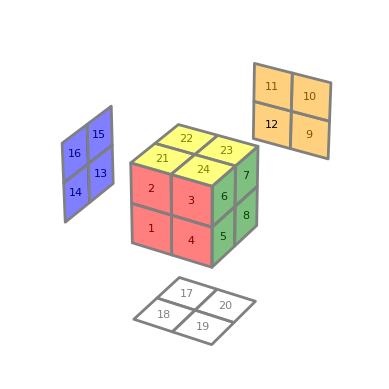

In [88]:
cube = Cube2x2()
cube.plot()

In [89]:
cube.apply(B)

<Axes3D: >

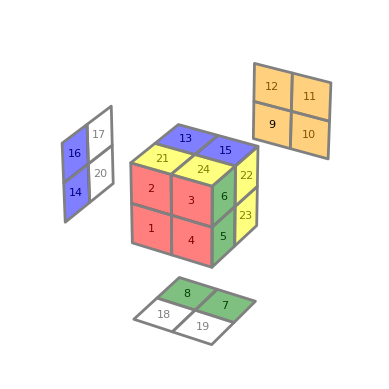

In [90]:
cube.plot(None)

In [91]:
cube.solve(bsgs_S24)

Solution found: BBB


BBB

In [92]:
cube.apply(R*R*R*T*T*T)

<Axes3D: >

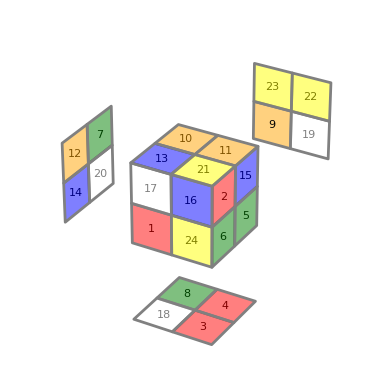

In [93]:
cube.plot()

In [94]:
cube.set_colors("ryrrggoowyyobborwwwgbbgy")

<Axes3D: >

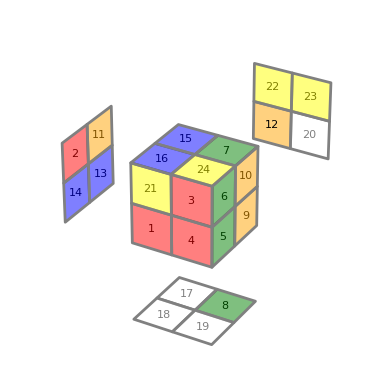

In [95]:
cube.plot()

In [96]:
solution = cube.solve(bsgs_S24)

Solution found: BTRTTTRTRTTTBRRRTRRRTTTBBTRTTTBRBBBTRRRTTTRRRBRBBBTRRRTTTRRRBBBTRTTTRTRTTTBRRRTRRRTTTBBTRTTTBBBRBBBTRRRTTTRRRBBTRTTTRTRTTTBRRRTRRRTTTBBTRTTTBRBBBTRRRTTTRRRBBTRTTTRTRTTTBRRRTRRRTTTBBTRTTTBRBBBTRRRTTTRRRBRBBBTRRRTTTRRRBBRTRTTTBRRRBBTRRRTTTBRBTTRRRT


In [97]:
solution.to_latex()


<IPython.core.display.Latex object>

<Axes3D: >

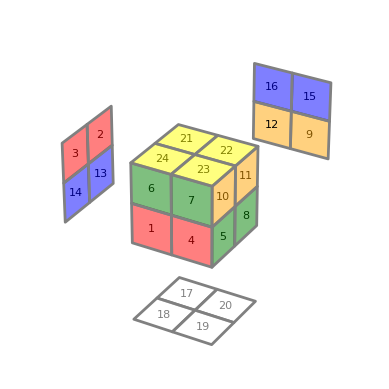

In [98]:
cube.reset()
cube.apply(T)
cube.plot()

<Axes3D: >

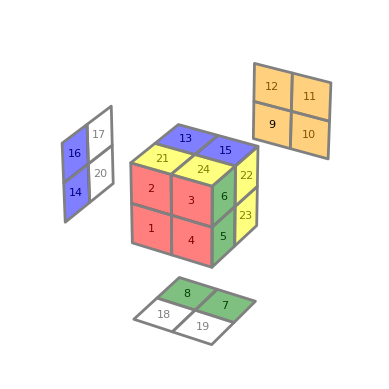

In [99]:
cube.reset()
cube.apply(B)
cube.plot()    

<Axes3D: >

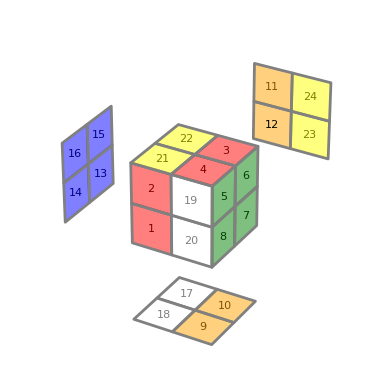

In [100]:
cube.reset()
cube.apply(R)
cube.plot()    

<Axes3D: >

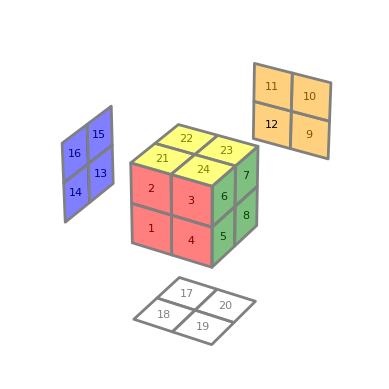

In [101]:
cube.reset()
cube.plot()    

<Axes3D: >

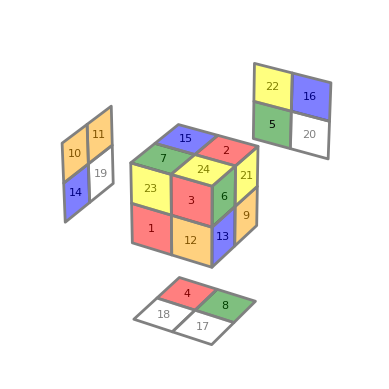

In [102]:
color_codes = "ryrobgyowbygwboorwwggbry"
cube.set_colors(color_codes)
cube.plot()

In [103]:
solution = cube.solve(bsgs_S24)

Solution found: TRTTTRTRTTTBRRRTRRRTTTBBTRTTTBBBRBBBTRRRTTTRRRBBTRTTTRTRTTTBRRRTRRRTTTBBTRTTTBRBBBTRRRTTTRRRBBRTRTTTBRRRBBBRTRTTTBRRRTRRRTTTBBTRTTTRBRRRTB


In [104]:
solution.to_latex()

<IPython.core.display.Latex object>

In [105]:
chunk_size = 10
actions = solution.actions
chunked_actions = [actions[i : i + chunk_size] for i in range(0, len(actions), chunk_size)]

# inspect result
len(actions), len(chunked_actions), [len(c) for c in chunked_actions], chunked_actions

(138,
 14,
 [10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 8],
 [[T, R, T, T, T, R, T, R, T, T],
  [T, B, R, R, R, T, R, R, R, T],
  [T, T, B, B, T, R, T, T, T, B],
  [B, B, R, B, B, B, T, R, R, R],
  [T, T, T, R, R, R, B, B, T, R],
  [T, T, T, R, T, R, T, T, T, B],
  [R, R, R, T, R, R, R, T, T, T],
  [B, B, T, R, T, T, T, B, R, B],
  [B, B, T, R, R, R, T, T, T, R],
  [R, R, B, B, R, T, R, T, T, T],
  [B, R, R, R, B, B, B, R, T, R],
  [T, T, T, B, R, R, R, T, R, R],
  [R, T, T, T, B, B, T, R, T, T],
  [T, R, B, R, R, R, T, B]])

In [106]:
[display(PermActionChain(actions=cas).to_latex()) for cas in chunked_actions];

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<Axes3D: >

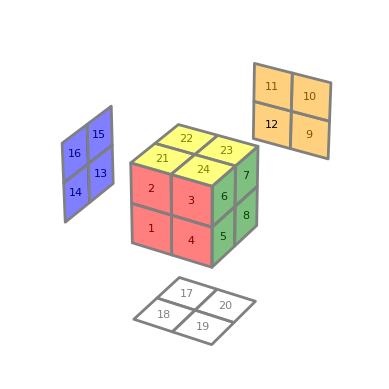

In [107]:
cube.apply(solution)
cube.plot()

<Axes3D: >

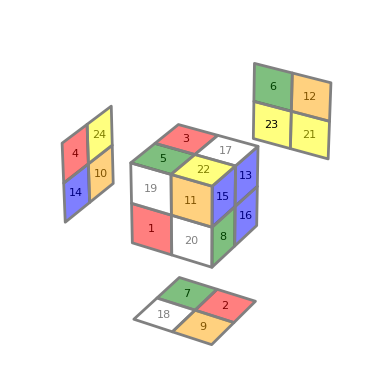

In [108]:
color_codes = "rwow"+"gbbb"+"yogy"+"obyr"+"gwor"+"grwy"
cube.set_colors(color_codes)
cube.plot()

In [109]:
solution = cube.solve(bsgs_S24)

Solution found: BTRTTTRTRTTTBRRRTRRRTTTBBTRTTTBRBBBTRRRTTTRRRBRBBBTRRRTTTRRRBBBTRTTTRTRTTTBRRRTRRRTTTBBTRTTTBBBRBBBTRRRTTTRRRBBTRTTTRTRTTTBRRRTRRRTTTBBTRTTTBRBBBTRRRTTTRRRBBRTRTTTBRRRBRTRTTTBRRRBRTRTTTBRRRBRTRTTTBRRRBTRRRTTTBBTRTTTRRBTTBR


<Axes3D: >

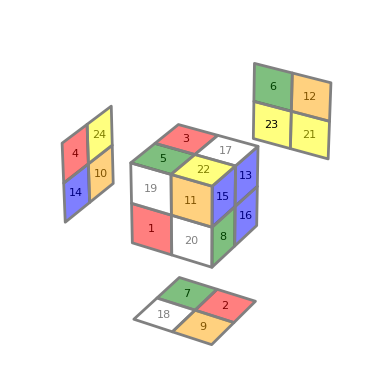

In [110]:
cube.plot()

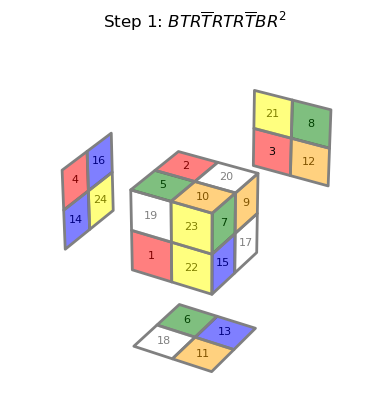

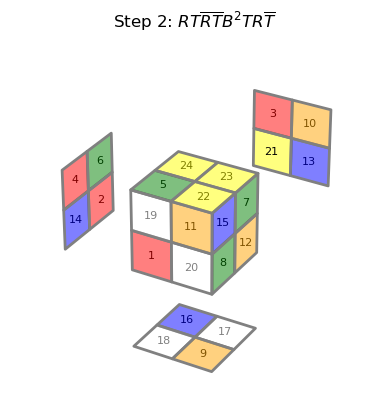

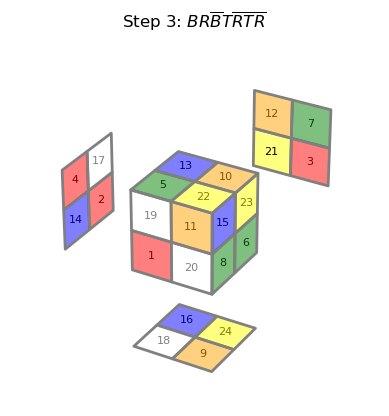

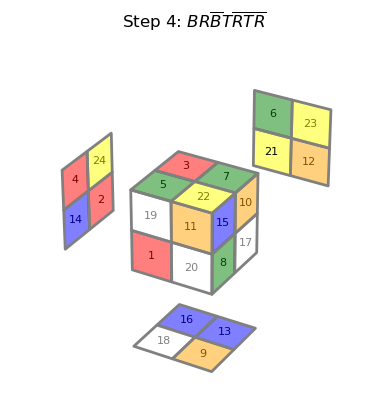

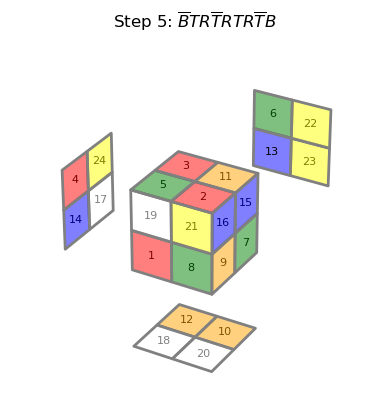

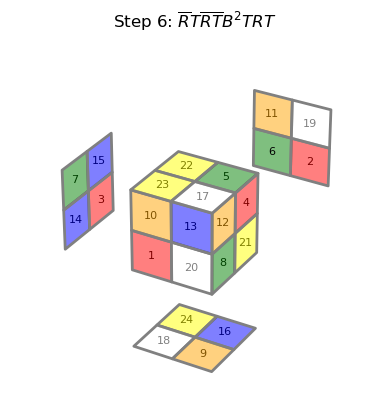

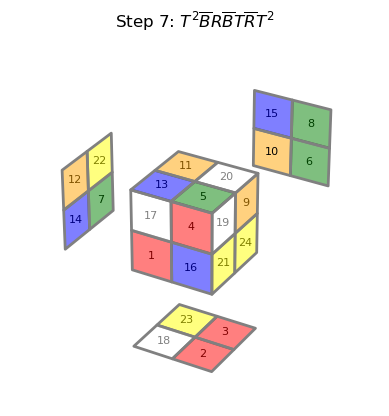

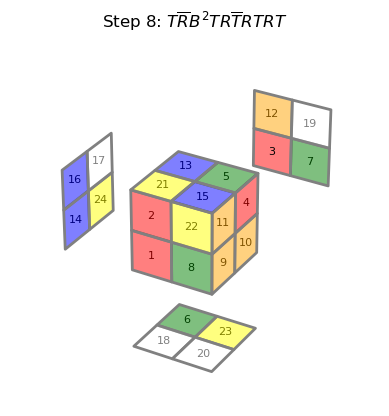

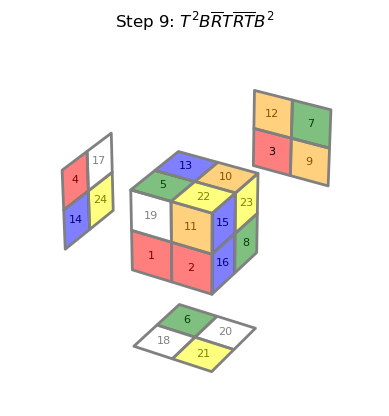

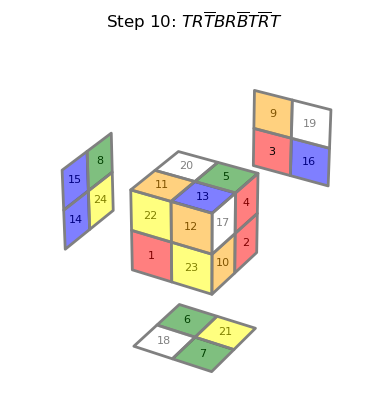

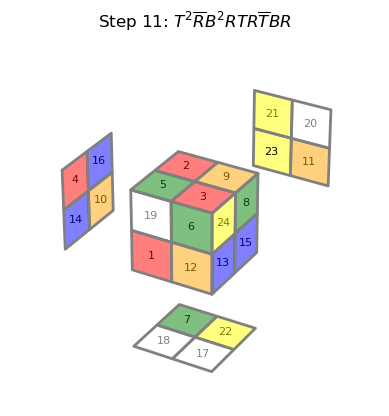

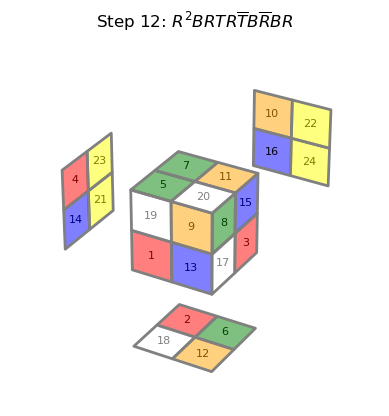

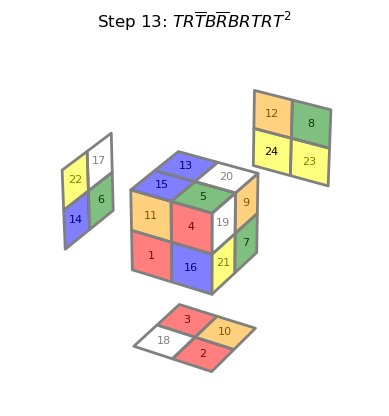

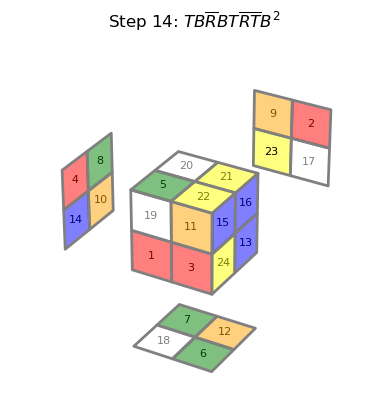

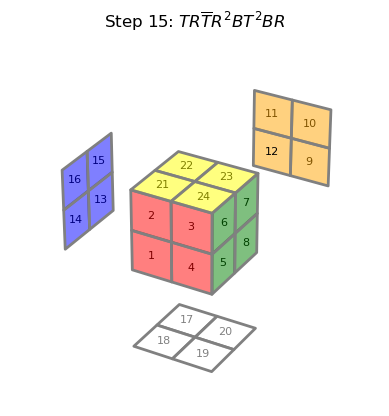

In [111]:
chunk_size = 15
actions = solution.actions
chunked_actions = [PermActionChain(actions=actions[i : i + chunk_size]) for i in range(0, len(actions), chunk_size)]
for i, cas in enumerate(chunked_actions):
    cube.apply(cas)
    ax = cube.plot()
    ax.set_title(f"Step {i+1}: {cas.to_latex().data}")

